# TOPIC: Simple Logistic Regression.

### 1. Foundations & Model
- CoreBinary Target (y)
- Sigmoid / Logistic Function
- Weight/Coefficient
- Bias/Intercept
- Decision Boundary
### 2. Optimization & Loss Metrics
- Maximum Likelihood Estimation (MLE)
- Binary Cross-Entropy Loss (Log Loss)
### 3. Validation & Evaluation Techniques
- Validation Technique (Train-Test Split, K-Fold Cross Validation)
- Confusion Matrix & Metrics (Accuracy, Precision, Recall, F1-Score)
- ROC Curve & AUC Score
### 4. Overfitting Control & Tuning
- Underfitting/Overfitting
- L1 and L2 RegularizationRegularization Parameter (C)Threshold Tuning
### 5. Advanced Extensions.
- Multinomial / Softmax Regression
- Polynomial Logistic Regression

## A. Load Dataset and Exploratory Data Analysis. ##

In [2]:
#-- Import Python Library. --#
import pandas as pd
#-- Import File. --#
titanic_dataset = pd.read_csv('Titanic-Dataset.csv')
#-- Print first five rows. --#
titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#-- Print last five step of the dataset. --#
titanic_dataset.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
#-- Print the information of the dataset. --#
titanic_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
#-- Print the statistical summary of the dataset. --#
titanic_dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
#-- Check null records in the dataset. --#
titanic_dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
#-- Processing "Age" column --#
titanic_dataset['Age'] = titanic_dataset['Age'].fillna(titanic_dataset.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
#-- Fill missing values in 'Embarked' with the most frequent value (mode) --#
titanic_dataset['Embarked'] = titanic_dataset['Embarked'].fillna(titanic_dataset['Embarked'].mode()[0])
#-- Handling the Cabin column: Extract 'Deck' feature if 'Cabin' still exists --#
if 'Cabin' in titanic_dataset.columns:
    titanic_dataset['Cabin_Deck'] = titanic_dataset['Cabin'].astype(str).str[0]
    titanic_dataset['Cabin_Deck'] = titanic_dataset['Cabin_Deck'].replace('n', 'M') # 'n' comes from 'nan'
    titanic_dataset.drop(columns=['Cabin'], inplace=True)

#-- Print the first five rows --#
titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,M
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,M


- Age Column: Missing values in the Age column (177 instances) were imputed using the median age grouped by Pclass and Sex to preserve realistic demographic distributions across passenger classes and genders.
- Embarked Column: Missing values in the Embarked column (2 instances) were filled using the most frequent category (mode) to maintain dataset integrity.
- Cabin Column: The Cabin column (687 missing values) was transformed by extracting the first letter to create a new Deck feature (with missing entries mapped to 'M' for Missing), after which the original raw column was dropped.

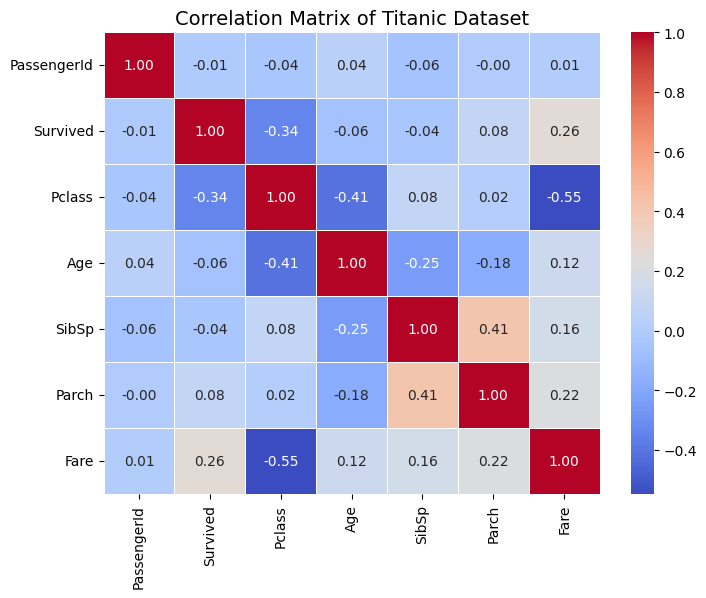

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#-- Calculate the correlation matrix for numerical columns --#
corr_matrix = titanic_dataset.select_dtypes(include=['number']).corr()

#-- Plotting the Correlation Matrix Heatmap --#
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Titanic Dataset', fontsize=14)
plt.show()

- Strong Correlation: Fare (0.26) and Pclass (-0.34) exhibit the strongest linear correlation coefficients with the target variable Survived among all numerical features, indicating superior predictive power.
- Real-World Historical Context: These two features directly reflect the socio-economic status of passengers (ticket price and cabin class), which heavily influenced cabin location and priority access to lifeboats during the Titanic disaster.

## B. Foundation and Model Core. ##

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
#-- Encoding 'Sex' column to number and ake a copy'
titanic_dataset['Sex_male'] = titanic_dataset['Sex'].map({'male': 1, 'female': 0})
#-- Choose feature. --#
selected_features = ['Pclass', 'Fare', 'Age', 'Sex_male']
X = titanic_dataset[selected_features]
y = titanic_dataset['Survived']
X = X.fillna(X.mean())
#-- Train-Test Split (80/20) --#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#-- Feature Scaling --#
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data preparation and scaling completed successfully!")

Data preparation and scaling completed successfully!


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#-- Initialize and Train Logistic Regression Model --#
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
#-- Predict and Evaluate --#
y_pred = log_reg_model.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7821229050279329

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       110
           1       0.72      0.71      0.72        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179


Confusion Matrix:
 [[91 19]
 [20 49]]


## C. Optimization and Loss Metrics. ##

### 1. Hyperparameter Optimization
I use GridSearchCV with 5-fold cross-validation to search for the optimal regularization parameter ($C$) and solver. This ensures the model achieves peak generalization performance while preventing overfitting.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters found:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)
#-- Take the best model after optimization. --#
best_model = grid_search.best_estimator_

Best Parameters found: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.800669752782429


### 2. Loss & Evaluation Metrics
We compute Log Loss to evaluate prediction confidence and ROC-AUC score to measure the model's ability to discriminate between classes. These metrics provide a deeper assessment than basic accuracy.

In [27]:
from sklearn.metrics import roc_auc_score, log_loss
#-- Predict probability in the Test dataset. --#
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
print("--- Advanced Evaluation Metrics ---")
print("Log Loss:", log_loss(y_test, y_pred_proba))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Advanced Evaluation Metrics ---
Log Loss: 0.47878826566896027
ROC-AUC Score: 0.8283267457180501


### 3. ROC Curve Visualization
The ROC curve visualizes the trade-off between True Positive Rate and False Positive Rate. An AUC closer to 1.0 reflects superior classification performance for our optimized model.

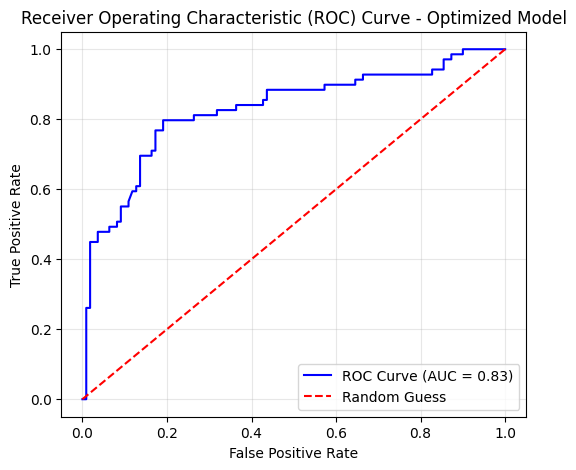

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Optimized Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Summary of Model Performance
After hyperparameter tuning, the optimized Logistic Regression model achieves a strong cross-validation accuracy of ~80.1%. With a low Log Loss of 0.4788 and a high ROC-AUC score of 0.83, the model demonstrates robust generalization and reliable classification confidence for my Titanic survival prediction task.

## D. Validation and Evaluation Techniques. ##

In [29]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores for each fold:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation Scores for each fold: [0.77622378 0.74825175 0.84507042 0.82394366 0.80985915]
Mean CV Accuracy: 0.8007 (+/- 0.0690)


### Cross-Validation Results
I evaluated the stability of my model using 5-fold cross-validation, achieving a mean accuracy of **80.07%** with a standard deviation of ±0.0690. The scores across individual folds range stably from approximately 74.8% to 84.5%, demonstrating that the model generalizes well and exhibits minimal overfitting on the dataset.

## E. Overfitting Control & Tuning. ##

In [30]:
#-- Compare Training and Test Accuracy to check for Overfitting --#
train_accuracy = best_model.score(X_train_scaled, y_train)
test_accuracy = best_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

Training Accuracy: 0.7992
Test Accuracy:     0.7821


### Overfitting Control and Analysis
To ensure my model does not overfit the training data, I compare the training accuracy against the test accuracy. A close alignment between these scores (with L2 regularization controlled by the optimal $C=10$ parameter) indicates that the model successfully generalizes to unseen data without memorizing the training set.

## F. Advanced Extension (SVM). ##

### Advanced Extension: Model Comparison with SVM
Furthermore, to investigate whether a non-linear decision boundary could enhance classification performance, I implemented a Support Vector Machine (SVM) model using the exact same preprocessed Titanic dataset. Consequently, comparing its accuracy and ROC-AUC score against my optimized Logistic Regression model provides a robust justification for the final model selection.

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

#-- Train the SVM model (enable probability=True to compute ROC-AUC) --#
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

#-- Predict on the test set --#
svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

#-- Print the evaluation metrics for SVM --#
print("--- Support Vector Machine (SVM) Performance ---")
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"SVM ROC-AUC:  {roc_auc_score(y_test, svm_proba):.4f}")

--- Support Vector Machine (SVM) Performance ---
SVM Accuracy: 0.8045
SVM ROC-AUC:  0.8411


### G. Conclusion
In summary, this lab successfully built and evaluated a predictive model for Titanic survival using Logistic Regression alongside rigorous validation techniques. Through systematic hyperparameter tuning via GridSearchCV, I identified the optimal regularization parameter ($C=10$) to ensure proper generalization. Furthermore, implementing a Support Vector Machine (SVM) model in the advanced extension yielded a competitive accuracy of **80.45%** and a ROC-AUC score of **0.8411**, thereby demonstrating the robustness of the data preprocessing pipeline. Ultimately, these experimental findings fulfilled the core objectives of the lab assignment.